In [1]:
import os
import farsight as fs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import synth_reader as sr
from astropy.io import fits
from astropy.table import Table
from joblib import Parallel, delayed

In [2]:
DF_original = pd.read_csv('~/HIIGalaxies/Spectral_synthesis/HIIGsample_stats.csv')


new_cols = ['STARLIGHT','FADO','LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR',
            'MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR',
            'SSFR','RED_LAW','BASE_SRC','N_BASE']

# 3. Creamos las nuevas columnas vacías con MultiIndex
# Usamos un diccionario de tuplas para que Pandas entienda la jerarquía
for main in new_cols:
    DF_original[main] = None

#DF.loc[0, "sSFR"] = 3



In [3]:
class Results_reader:
    def __init__(self,home,data_frame,software,law_key): # Input file name & file directory and distance in Mpc o z
        self.home = home
        self.data_frame = data_frame
        self.software = software
        self.law_key = law_key

    def get_individual_data(self,idx = '', dist = None):
        if self.software == 'FADO':
            spec = fs.Fado(home = self.home,
                        file = idx,
                        distance = dist)
        if self.software == 'STARLIGHT':
            spec = fs.Starlight(home = self.home,
                        file = idx,
                        distance = dist)
        
        data = {'CHI2':      [  spec.metadata['chi2']                , r'$\mathbfit{\chi^2 / \nu}$'               ], 
                'ADEV':      [  spec.metadata['adev']                , r'$\mathbfit{Adev}$'                       ],
                'A_V':       [  spec.metadata['A_V']                 , r'$\mathbfit{A_{V\star}}$'                 ],
                'A_NEB':     [  spec.metadata['A_Neb']               , r'$\mathbfit{A_{V Neb}}$'                  ],
                'V_STAR':    [  spec.metadata['v_star']              , r'$\mathbfit{v {\star}}$'                  ],
                'S_STAR':    [  spec.metadata['s_star']              , r'$\mathbfit{\sigma {\star}}$'             ],
                'MEAN_LGTL': [  spec.metadata['mean_logt_L']         , r'$\mathbfit{\langle log\,t \rangle_L}$'   ],
                'MEAN_LGTM': [  spec.metadata['mean_logt_M']         , r'$\mathbfit{\langle log\,t \rangle_M}$'   ],
                'MEAN_ZL':   [  spec.metadata['mean_Z_L']            , r'$\mathbfit{\langle Z \rangle_L}$'        ], 
                'MEAN_ZM':   [  spec.metadata['mean_Z_M']            , r'$\mathbfit{\langle Z \rangle_M}$'        ],
                'MIT':       [  spec.metadata['minitot']             , r'$\mathbfit{MassINItotal}$'               ],
                'MCT':       [  spec.metadata['mcortot']             , r'$\mathbfit{MassCORtotal}$'               ],
                'LG_MIT':    [  spec.distance_derived['log_mitot']   , r'$\mathbfit{lgMassINItotal}$'             ],  
                'LG_MCT':    [  spec.distance_derived['log_mctot']   , r'$\mathbfit{lgMassCORtotal}$'             ],
                'SFR':       [  spec.distance_derived['sfr_0']       , r'$\mathbfit{SFR}$'                        ],
                'SSFR':      [  spec.distance_derived['ssfr_0']      , r'$\mathbfit{sSFR}$'                       ],
                'RED_LAW':   [  spec.metadata['red_law']             , r'$\mathbfit{Reddening \, law}$'           ],
                'BASE_SRC':  [  spec.metadata['base_src']            , r'$\mathbfit{Base \, source}$'             ],
                'N_BASE':    [  spec.metadata['n_base']              , r'$\mathbfit{N \, base}$'                  ],
                'LAMBDA_N':  [  spec.metadata['lambda_norm']         , r'$\mathbfit{\lambda (\AA)}$'              ]
                }
        
        return data


        

    def get_bulk_data(self):
        _cols = ['LAMBDA_N','CHI2','ADEV','A_V','A_NEB','V_STAR','S_STAR',
                 'MEAN_LGTL','MEAN_LGTM','MEAN_ZL','MEAN_ZM','MIT','MCT','LG_MIT','LG_MCT','SFR',
                 'SSFR','RED_LAW','BASE_SRC','N_BASE']
        path = self.home
        if self.software == 'FADO':
            spec_list = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
            spec_list.sort()
        if self.software == 'STARLIGHT':
            spec_list = [f for f in os.listdir(path) if f.endswith('.out')]
            spec_list.sort()
        spec_list = [item for item in spec_list if self.law_key in item]
        DF = self.data_frame.copy()
        for file_name in spec_list:
            idx_val = int(file_name[0:3])
            mask = DF['TAB5_INDEX'] == idx_val
            z = DF.loc[mask, 'Z'].iloc[0]
            results = self.get_individual_data(idx = file_name, dist = z)
            DF.loc[mask, "FADO"] = (self.software == 'FADO')
            DF.loc[mask, "STARLIGHT"] = (self.software == 'STARLIGHT')
            for lbl in _cols:
                DF.loc[mask, lbl] = results[lbl][0]
        return DF
                

In [4]:
FD_CAL_4020 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','CALR').get_bulk_data()
FD_GD1_4020 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR1').get_bulk_data()
FD_GD2_4020 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR2').get_bulk_data()
FD_GD3_4020 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR3').get_bulk_data()

#CAL_5100 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','CALR').get_bulk_data()
#GD1_5100 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR1').get_bulk_data()
#GD2_5100 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR2').get_bulk_data()
#GD3_5100 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR3').get_bulk_data()

#CAL_4150 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','CALR').get_bulk_data()
#GD1_4150 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR1').get_bulk_data()
#GD2_4150 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR2').get_bulk_data()
#GD3_4150 = Results_reader('/home/hollman/Documents/o_FR4020/',DF_original,'FADO','GOR3').get_bulk_data()

SL_CAL_4020 = Results_reader('/home/hollman/Documents/out_FR4020/',DF_original,'STARLIGHT','CAL').get_bulk_data()
SL_GD1_4020 = Results_reader('/home/hollman/Documents/out_FR4020/',DF_original,'STARLIGHT','GD1').get_bulk_data()
SL_GD2_4020 = Results_reader('/home/hollman/Documents/out_FR4020/',DF_original,'STARLIGHT','GD2').get_bulk_data()
SL_GD3_4020 = Results_reader('/home/hollman/Documents/out_FR4020/',DF_original,'STARLIGHT','GD3').get_bulk_data()

s_srCAL = SL_CAL_4020[SL_CAL_4020['TAB5_INDEX']!=56]
f_srCAL = FD_CAL_4020[FD_CAL_4020['TAB5_INDEX']!=56]
s_srGD1 = SL_GD1_4020[SL_GD1_4020['TAB5_INDEX']!=56]
f_srGD1 = FD_GD1_4020[FD_GD1_4020['TAB5_INDEX']!=56]
s_srGD2 = SL_GD2_4020[SL_GD2_4020['TAB5_INDEX']!=56]
f_srGD2 = FD_GD2_4020[FD_GD2_4020['TAB5_INDEX']!=56]
s_srGD3 = SL_GD3_4020[SL_GD3_4020['TAB5_INDEX']!=56]
f_srGD3 = FD_GD3_4020[FD_GD3_4020['TAB5_INDEX']!=56]

STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/001.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/002.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/003.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/004.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/005.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/006.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/007.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/008.CAL.MILES150.fits
STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/009.CAL.MILES150.fits
STARLIGHT .fits file transfo

In [26]:
print(np.unique(f_srCAL['RED_LAW']))
print(np.unique(f_srGD1['RED_LAW']))
print(np.unique(f_srGD2['RED_LAW']))
print(np.unique(f_srGD3['RED_LAW']))

['Calzetti et al. (2000)']
['Gordon et al. 2003 - SMC Bar']
['Gordon et al. 2003 - LMC SuperShell']
['Gordon et al. 2003 - LMC Average']


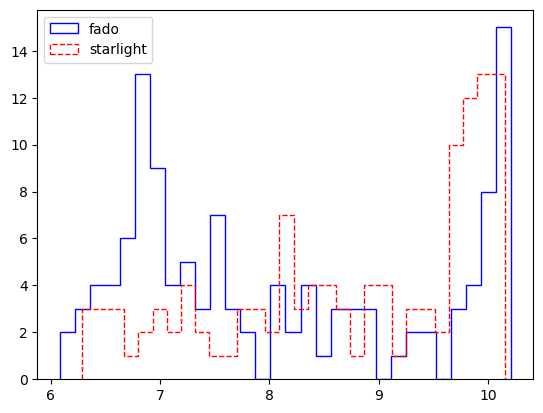

In [34]:
plt.hist(f_srCAL['MEAN_LGTM'], bins=30, alpha=1, color='blue', edgecolor='blue',histtype='step',label = 'fado',linestyle='-')
plt.hist(s_srCAL['MEAN_LGTM'], bins=30, alpha=1, color='blue', edgecolor='red',histtype='step',label = 'starlight',linestyle='--')
#plt.hist(f_srCAL['SFR'], bins=30, alpha=1, color='blue', edgecolor='red',histtype='step',label = 'fado',linestyle='--')

plt.legend()

In [372]:
np.log10(10)

1.0

STARLIGHT .fits file transformed before. Location: /home/hollman/Documents/out_FR4020/056.GD1.MILES150.fits


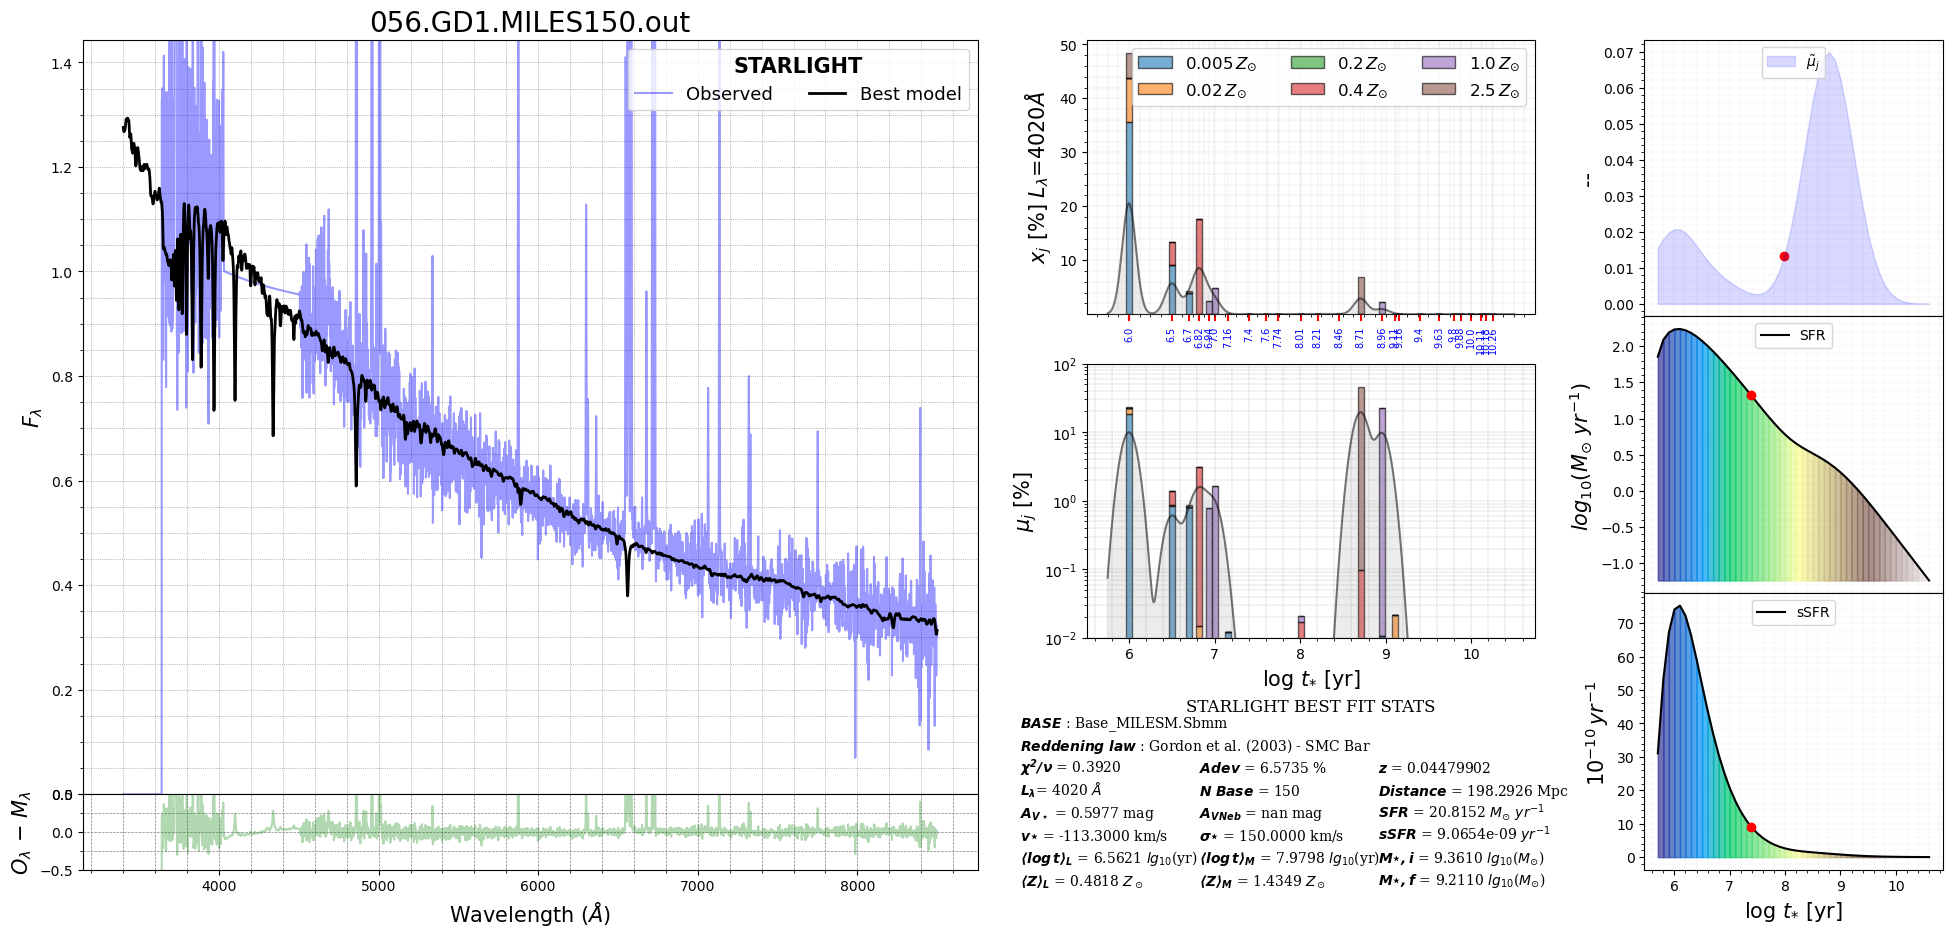

In [19]:
obj = '056'

spec = fs.Starlight(home = '/home/hollman/Documents/out_FR4020/',file = f'{obj}.GD1.MILES150.out', distance = DF_original[DF_original['TAB5_INDEX']>=int(obj)]['Z'].iloc[0])

spec.CompositePlot()


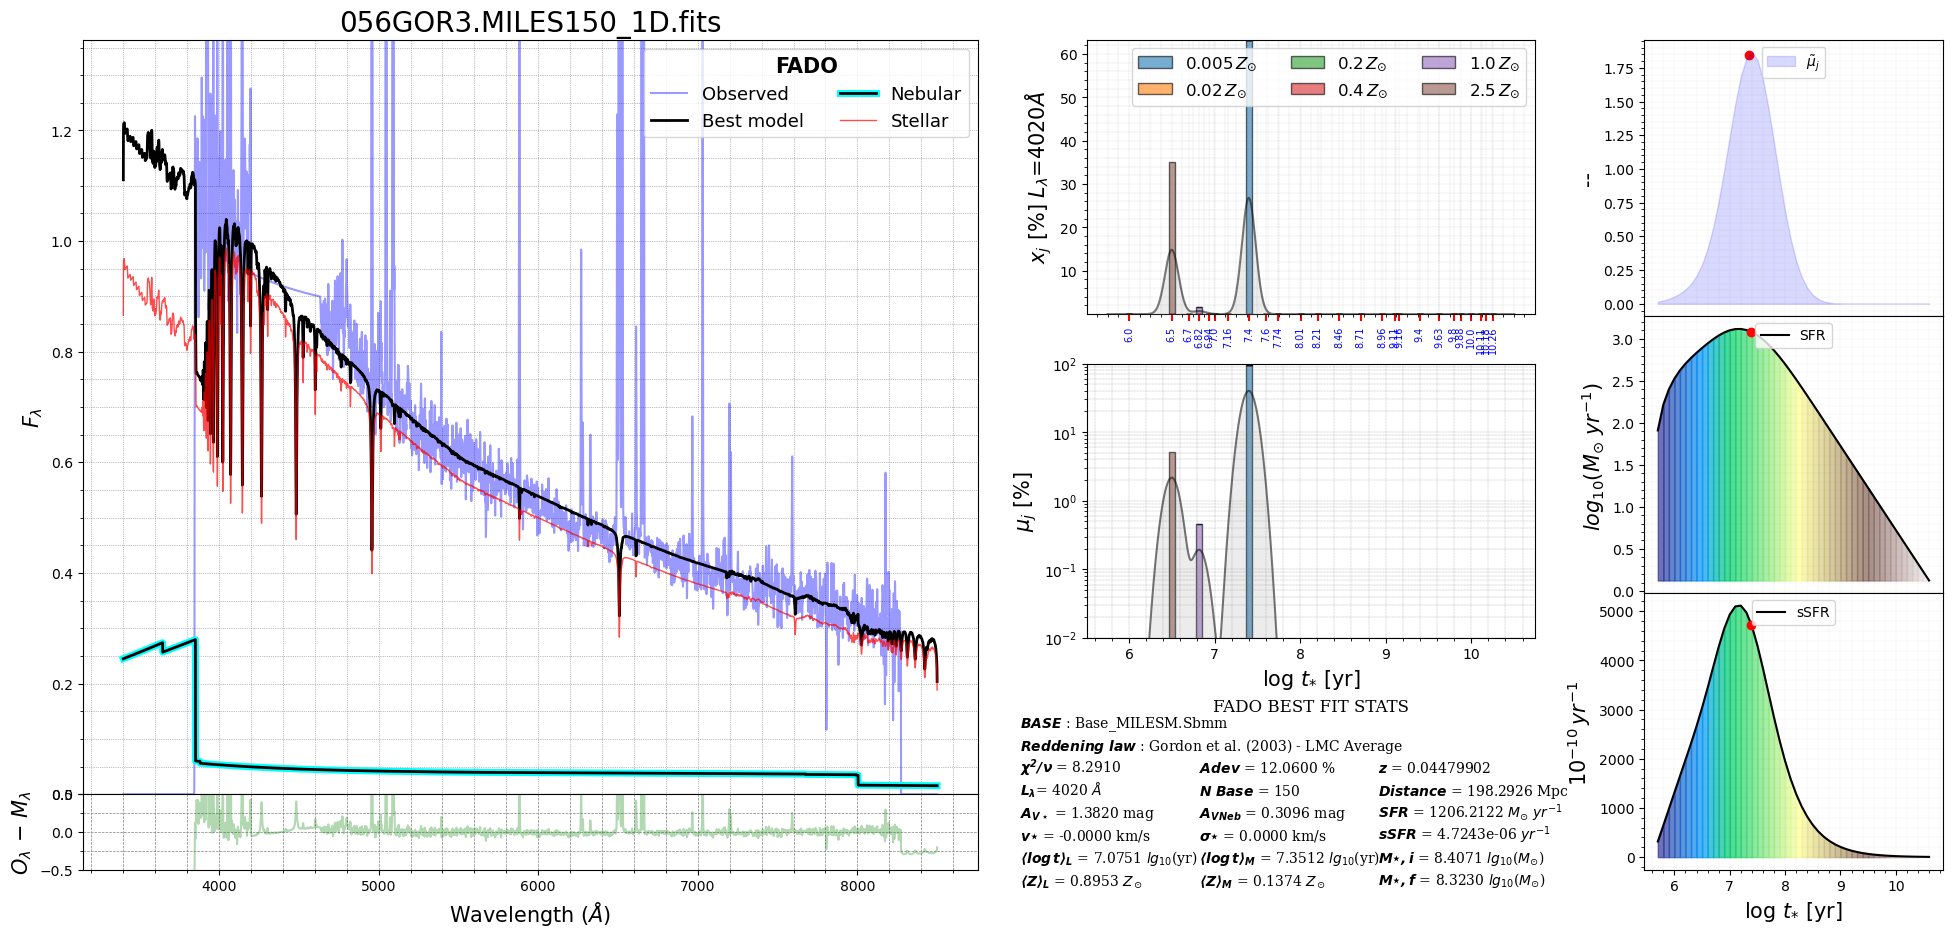

In [10]:
obj = '056'

spec = fs.Fado(home = '/home/hollman/Documents/o_FR4020/',file = f'{obj}GOR3.MILES150_1D.fits', distance = DF_original[DF_original['TAB5_INDEX']>=int(obj)]['Z'].iloc[0])

spec.CompositePlot()


In [ ]:
fits_name = 'Synthesis_runs.fits'
rands_x1hdu = np.random.random((1,1))
primary_hdu = fits.PrimaryHDU(data=rands_x1hdu)
HDU = fits.HDUList([primary_hdu])
lista_HDUs = [primary_hdu]
HDU_final = fits.HDUList(lista_HDUs)
HDU_final.writeto(fits_name, overwrite=True)


In [39]:
def merit_stats(path, title, snr_threshold, DF_path, 
                ext_laws=['Calzetti','Gordon1','Gordon2','Gordon3'], 
                attributes=[[r'$\chi^2$', 'Adev'], [0, 1]]):
    
    # 1. Filtro de SNR
    df_data = pd.read_csv(DF_path)
    valid_ids = df_data.loc[df_data['SDSS_SNR'] >= snr_threshold, 'TAB5_INDEX'].astype(str).tolist()
    
    # 2. Filtrar archivos (rellenamos con ceros si el ID en el nombre tiene formato 001)
    spec_list = [f for f in os.listdir(path) if f.endswith('_1D.fits')]
    chosen_spec = [f for f in spec_list if f[:3].lstrip('0') in [i.lstrip('0') for i in valid_ids]]
    chosen_spec.sort()

    # 3. Preparar estructura de resultados: una lista por cada celda del subplot
    # Si hay 2 atributos y 4 leyes, necesitamos 8 listas
    num_attrs = len(attributes[0])
    num_laws = len(ext_laws)
    results = [[] for _ in range(num_attrs * num_laws)]
    
    # Mapeo de keywords en el nombre de archivo a su índice de columna
    law_map = {'CALR': 0, 'GOR1': 1, 'GOR2': 2, 'GOR3': 3}

    # 4. Lectura de datos
    for filename in chosen_spec:
        # Identificar qué ley de extinción es
        law_idx = next((idx for key, idx in law_map.items() if key in filename), None)
        
        if law_idx is not None:
            # Leer el archivo una sola vez por eficiencia
            full_data = sr.FADO_results_reader(id=filename, home=path)
            
            for attr_row in range(num_attrs):
                # El índice final es: (fila_atributo * total_columnas) + columna_ley
                final_idx = (attr_row * num_laws) + law_idx
                val = full_data[attributes[1][attr_row]]
                results[final_idx].append(val)

    # 5. Graficar
    fig, axes = plt.subplots(nrows=num_attrs, ncols=num_laws, 
                             figsize=(16, 4 * num_attrs), sharey=False)
    fig.suptitle(title, fontsize=20, fontweight='bold')
    
    label_extlaws = ext_laws * num_attrs
    name_col = [label for label in attributes[0] for _ in range(num_laws)]

    for i, ax in enumerate(axes.flat):
        if not results[i]: continue # Evitar error si una lista quedó vacía
        
        ax.hist(results[i], bins=25, color='skyblue', edgecolor='black', alpha=0.7)
        
        stats = [np.mean(results[i]), np.median(results[i]), np.max(results[i]), np.min(results[i])]
        colors = ['r', 'g', 'b', 'c']
        labels = ['Mean', 'Median', 'Max', 'Min']
        
        for s, c, l in zip(stats, colors, labels):
            ax.axvline(s, color=c, linestyle='dashed', linewidth=2, label=f'{l}: {s:.2f}')
        
        ax.set_title(label_extlaws[i])
        ax.set_xlabel(name_col[i], fontsize=12, color='darkred')
        ax.legend(title=f'N = {len(results[i])}', fontsize='small')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

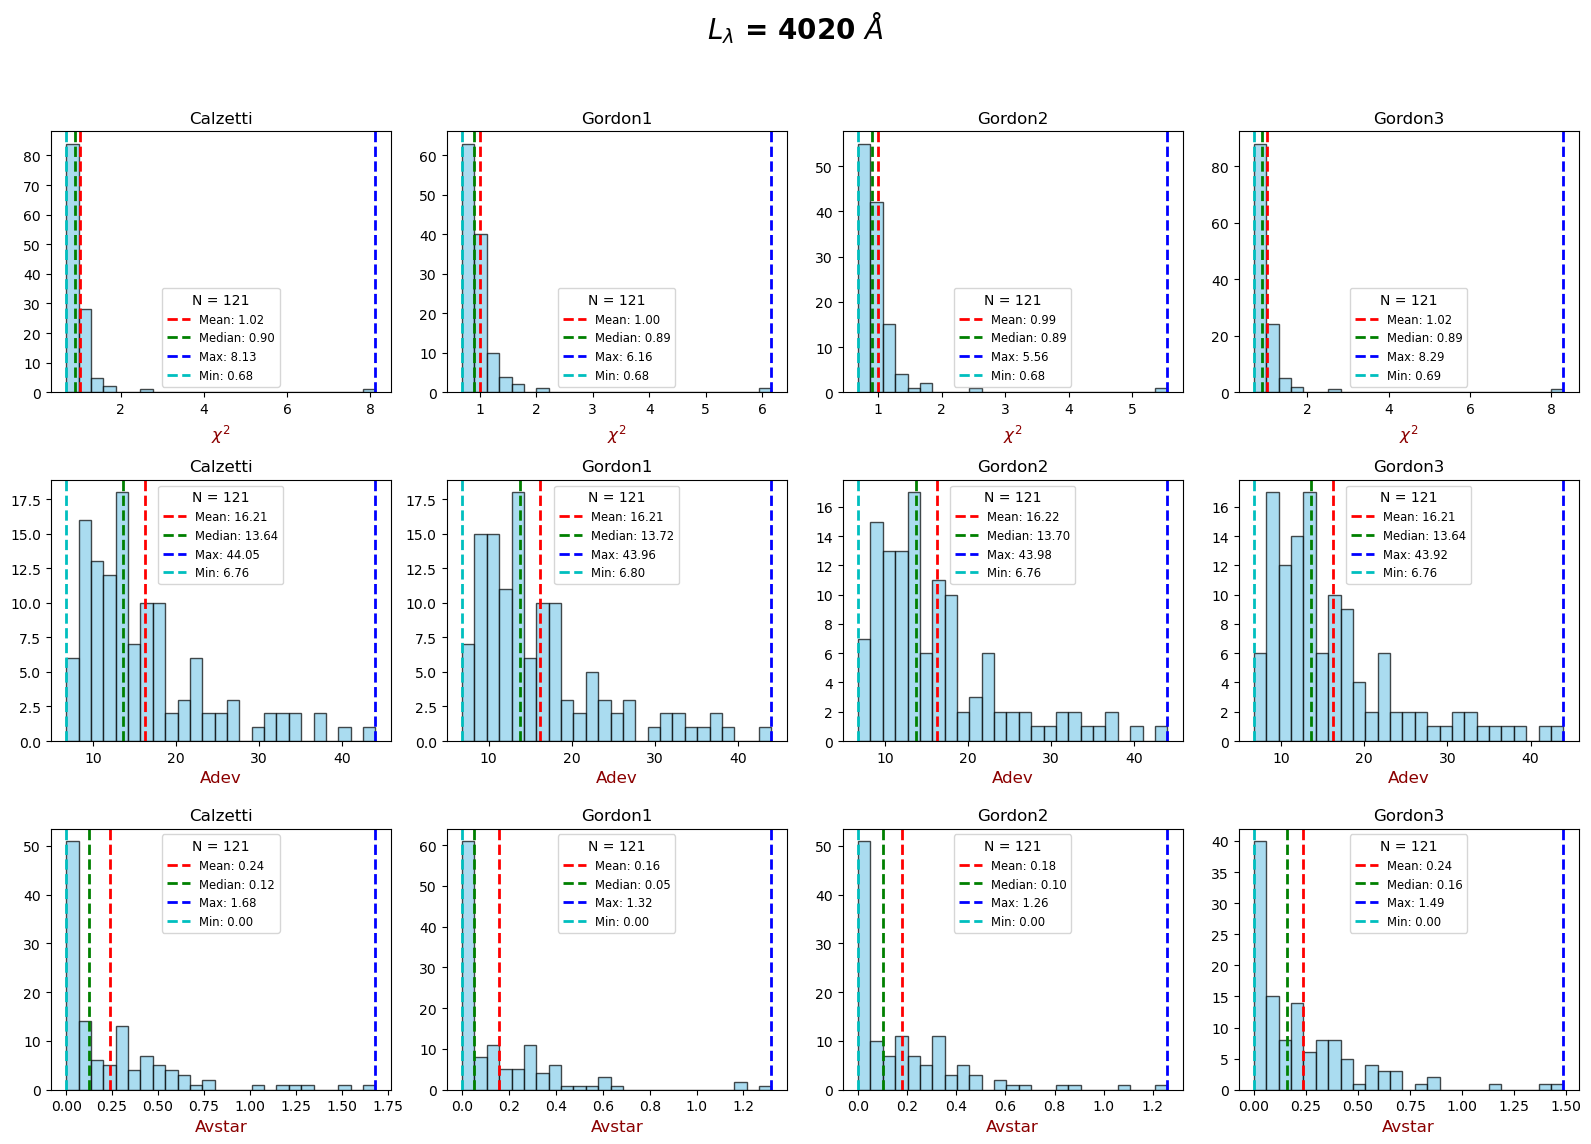

In [40]:
merit_stats(path ='/home/hollman/Documents/o_FR4020/',
            title=r'$L_{\lambda}$ = 4020 $\AA$',
            snr_threshold=0,
            DF_path='/home/hollman/HIIGalaxies/Spectral_synthesis/HIIGsample_data.csv',
            attributes = [[r'$\chi^2$',r'Adev',r'Avstar'],[0,1,2]])